In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

visa_df=pd.read_csv(r'C:\Users\omkar\OneDrive\Documents\Gen_AI\Data_files\Visadataset.csv')
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

**Why scaling**

- Scaling presreve the numerical statbility across the columns

    - Ex:  Age : 20   Salary: 50000  Exp: 2

    - different columns having the different scale(limit)

    - we want to keep all the columns under same limit

    - if we dont keep under same scale some ML algo feels salary is the importnt column
        - becuase of the highest value

- **Faster training**

    - Some of ML algorithms like **KNN,KMEANS,SVM** are distance based algortihmns

    - if we lower the values the calculations are fast

    - In every Model development will do math calculations

    - In order to increase the fastness(optimization) scaling is very helpful


**Z scale**

<img src="https://www.thedataschool.co.uk/content/images/2023/02/image-66.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 435px; height: 228px; margin: 0px; width: 279px;" alt="Z Score - An overview with examples - The Data School" jsname="kn3ccd">

In [8]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [10]:
wage_data=visa_df['prevailing_wage']
# step-1: wage_mean=wage_data.mean()
# step-2: wage_sd
# step-3: Nr=wage_data-wage_mean
# step-4: Nr/wage_sd


In [12]:
wage_mean=wage_data.mean()
wage_sd=wage_data.std()
Nr=wage_data-wage_mean
wage_z=Nr/wage_sd

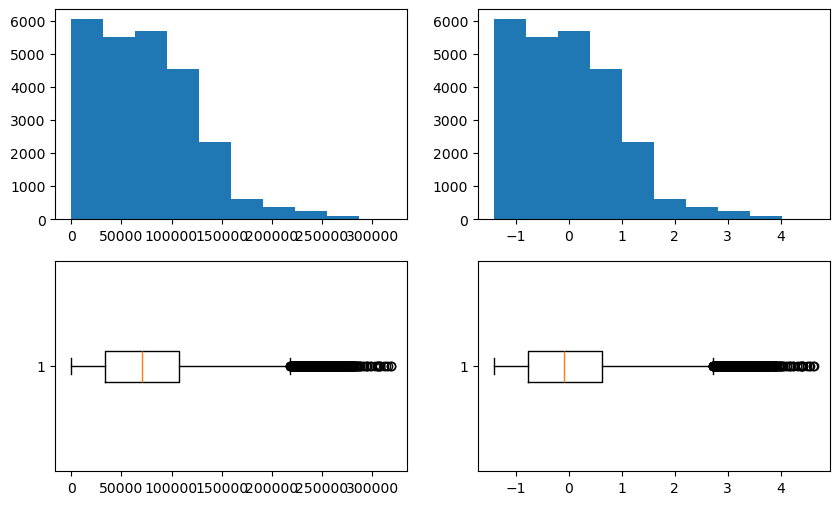

In [16]:
# old_data: wage_data
# z_data  : wage_z
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

- sklearn

    - preprocessing

        - StatndardScalar

            - fit_transform

In [21]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_data_ss=ss.fit_transform(visa_df[['prevailing_wage']])

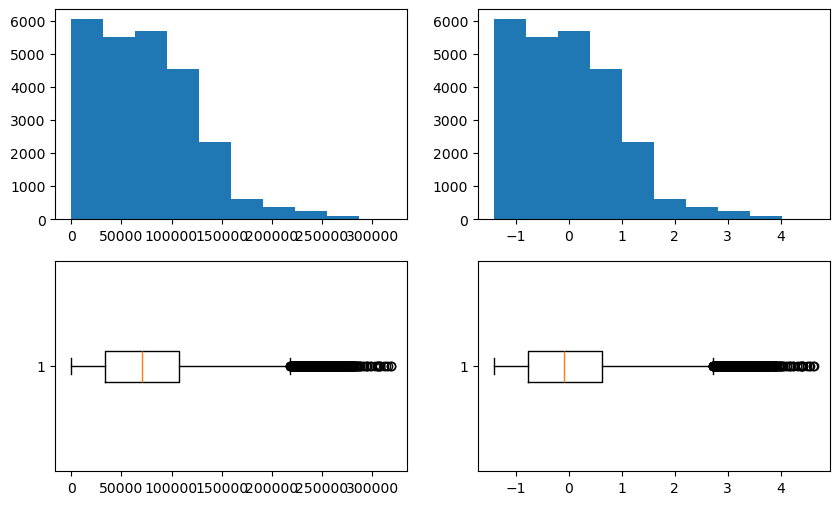

In [23]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_data_ss)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_data_ss,vert=False)
plt.show()

**Normalization**

<img src="https://www.oreilly.com/api/v2/epubs/urn:orm:book:9781788393485/files/assets/545d977f-9de2-4280-b08a-0436149980c5.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 1770px; height: 85px; margin: 30.5px 0px; width: 357px;" alt="Min–max normalization - Hands-On Machine Learning on Google Cloud Platform  [Book]" jsname="kn3ccd">

In [ ]:
# step-1: wage_min
# step-2: wage_max
# step-3: Nr=wage_data-wage_min
# step-4: Dr= wage_max-wage_min
# step-5: wage_norm=Nr/Dr

# StandardScalar is  called as a Z score
# MinMaxScalar is  called as Norm 0 to 1

- sklearn

    - preprocessing

        - MinMaxScalar

            - fit_trainform